# VLM Evaluation — CLIP & DermLIP
Loads saved results from `results/vlm/` and evaluates zero-shot performance across all prompt templates.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import sys
import re

ROOT       = os.path.abspath(os.path.join(os.getcwd(), '..'))
VLM_DIR    = os.path.join(ROOT, 'results', 'vlm')
CLIP_DIR   = os.path.join(VLM_DIR, 'clip')
DERM_DIR   = os.path.join(VLM_DIR, 'dermlip')

sys.path.insert(0, os.path.join(ROOT, 'src'))
from dataset import CLASS_NAMES

def load_summary(model_dir):
    with open(os.path.join(model_dir, 'summary.json')) as f:
        return json.load(f)

def load_report(model_dir, tmpl_name):
    path = os.path.join(model_dir, tmpl_name, 'classification_report.txt')
    with open(path) as f:
        return f.read()

clip_summary = load_summary(CLIP_DIR)
derm_summary = load_summary(DERM_DIR)

TEMPLATES = list(clip_summary['prompt_sweep'].keys())
print(f'Templates: {TEMPLATES}')
print(f'CLIP best:    {clip_summary["best_config"]["template"]}')
print(f'DermLIP best: {derm_summary["best_config"]["template"]}')

Templates: ['label_only', 'dermoscopy', 'dermatoscopic', 'skin_lesion', 'this_is', 'photo_of', 'clinical']
CLIP best:    clinical
DermLIP best: this_is


---
# Section 1 — CLIP

## Prompt Sweep Table

In [2]:
sweep = clip_summary['prompt_sweep']
best  = clip_summary['best_config']['template']

print(f"{'Template':<20}  {'Template String':<45}  {'Accuracy':>10}  {'Macro AUC':>10}  {'Micro AUC':>10}")
print('-' * 100)
for name, r in sweep.items():
    marker = ' <-- best' if name == best else ''
    print(f"{name:<20}  {r['template']:<45}  {r['accuracy']:>9.2f}%  {r['macro_auc']:>10.4f}  {r['micro_auc']:>10.4f}{marker}")

Template              Template String                                  Accuracy   Macro AUC   Micro AUC
----------------------------------------------------------------------------------------------------
label_only            {c}                                                 5.99%      0.5933      0.2944
dermoscopy            a dermoscopy image of {c}                          11.58%      0.6141      0.3429
dermatoscopic         a dermatoscopic image of {c}                       11.18%      0.6010      0.2957
skin_lesion           a skin lesion showing {c}                          11.38%      0.6008      0.3555
this_is               this is a skin image of {c}                        10.98%      0.6134      0.2882
photo_of              a photo of {c}                                     11.38%      0.5994      0.3199
clinical              a clinical photograph of {c}                       11.88%      0.6079      0.3241 <-- best


## Confusion Matrices — All Prompts

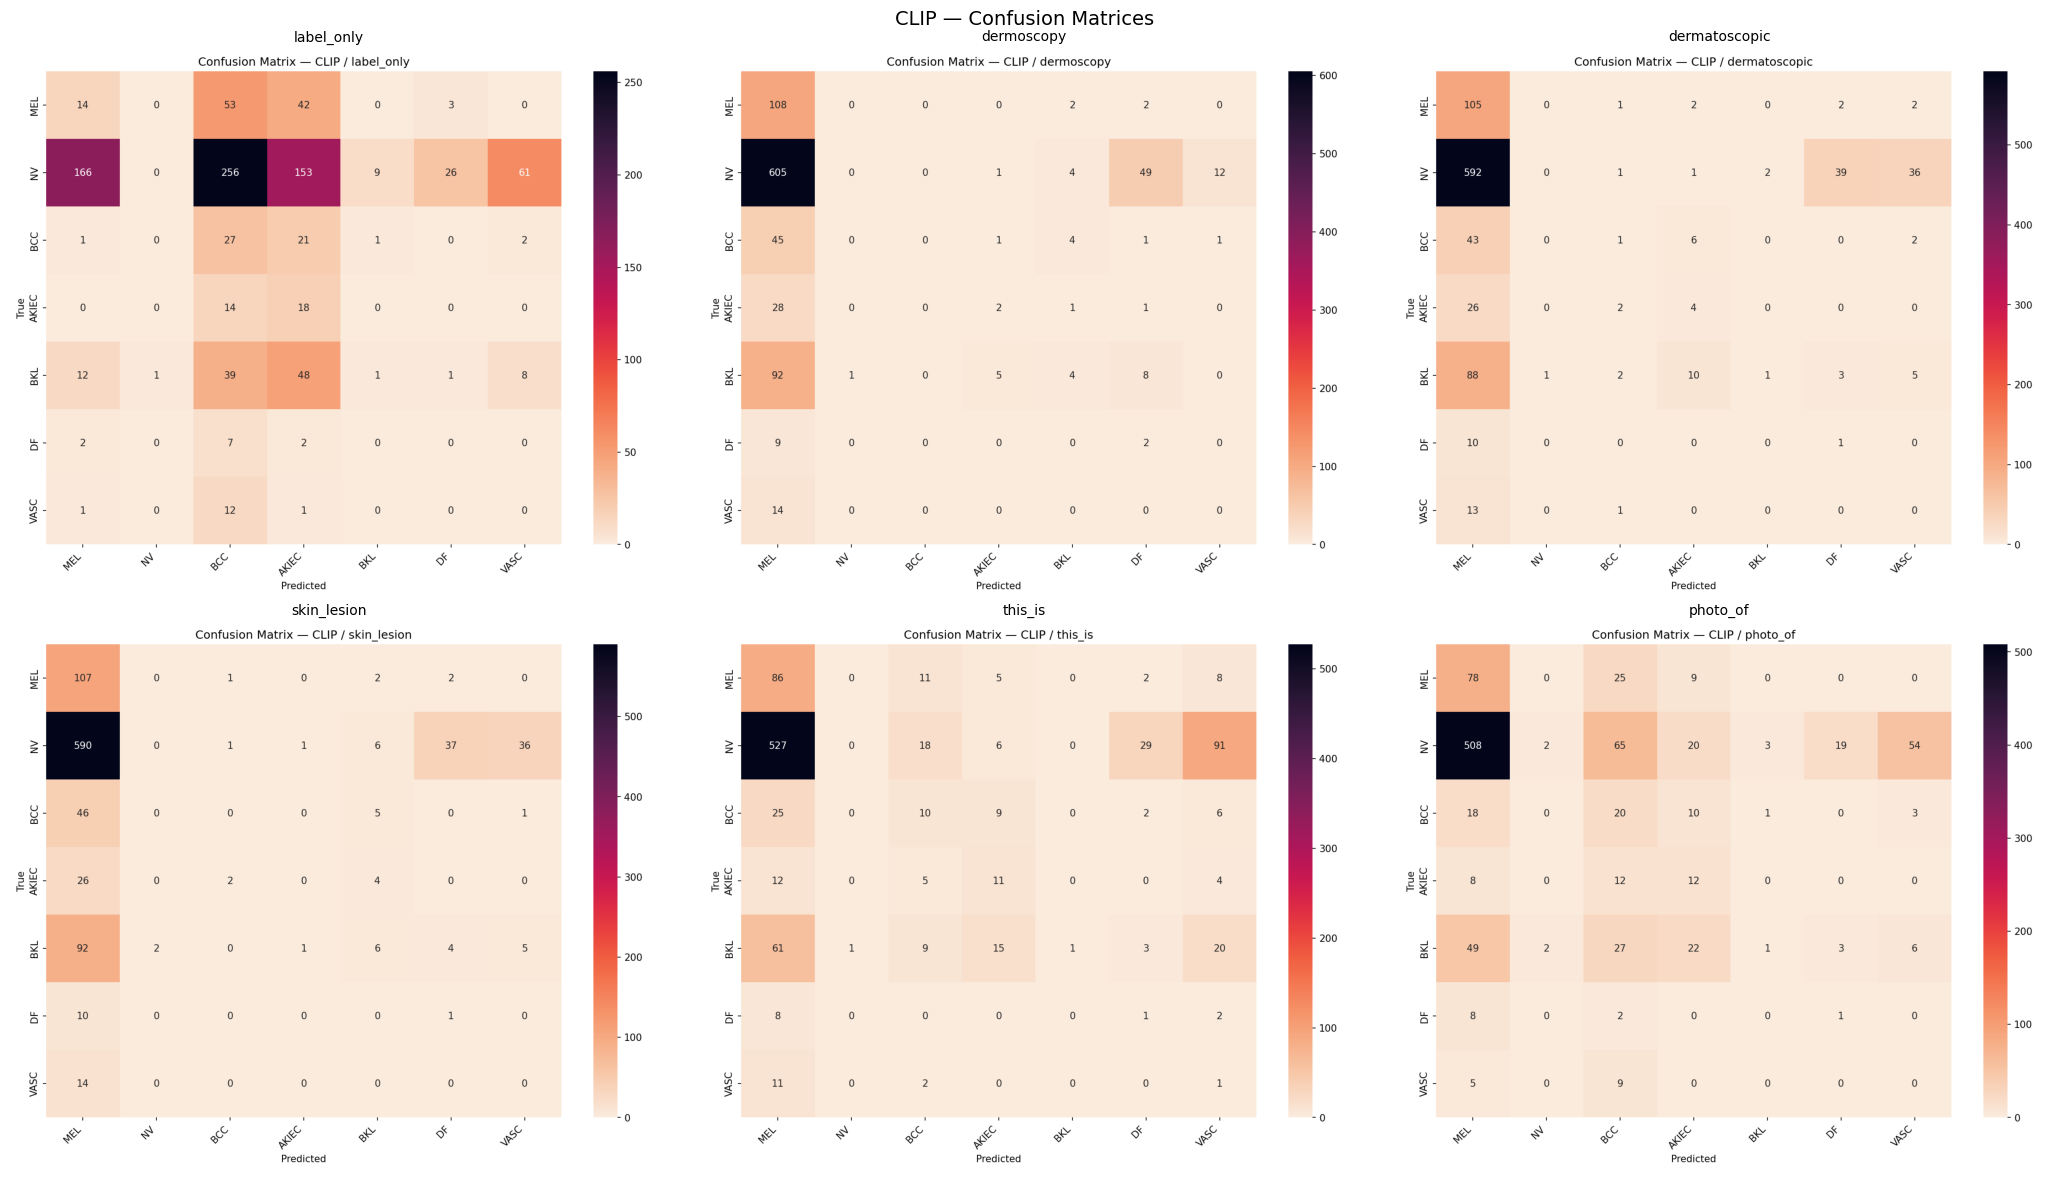

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
axes_flat = axes.flatten()
for ax, tmpl in zip(axes_flat, TEMPLATES):
    img_path = os.path.join(CLIP_DIR, tmpl, 'confusion_matrix.png')
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(tmpl, fontsize=10)
    ax.axis('off')
# hide any unused axes if fewer than 6 templates
for ax in axes_flat[len(TEMPLATES):]:
    ax.axis('off')
plt.suptitle('CLIP — Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

## Classification Reports — All Prompts

In [4]:
for tmpl in TEMPLATES:
    print(f'\n--- CLIP / {tmpl} ---')
    print(load_report(CLIP_DIR, tmpl))


--- CLIP / label_only ---
Model: CLIP
Template: label_only — "{c}"

              precision    recall  f1-score   support

         MEL       0.07      0.12      0.09       112
          NV       0.00      0.00      0.00       671
         BCC       0.07      0.52      0.12        52
       AKIEC       0.06      0.56      0.11        32
         BKL       0.09      0.01      0.02       110
          DF       0.00      0.00      0.00        11
        VASC       0.00      0.00      0.00        14

    accuracy                           0.06      1002
   macro avg       0.04      0.17      0.05      1002
weighted avg       0.02      0.06      0.02      1002


--- CLIP / dermoscopy ---
Model: CLIP
Template: dermoscopy — "a dermoscopy image of {c}"

              precision    recall  f1-score   support

         MEL       0.12      0.96      0.21       112
          NV       0.00      0.00      0.00       671
         BCC       0.00      0.00      0.00        52
       AKIEC       0.22   

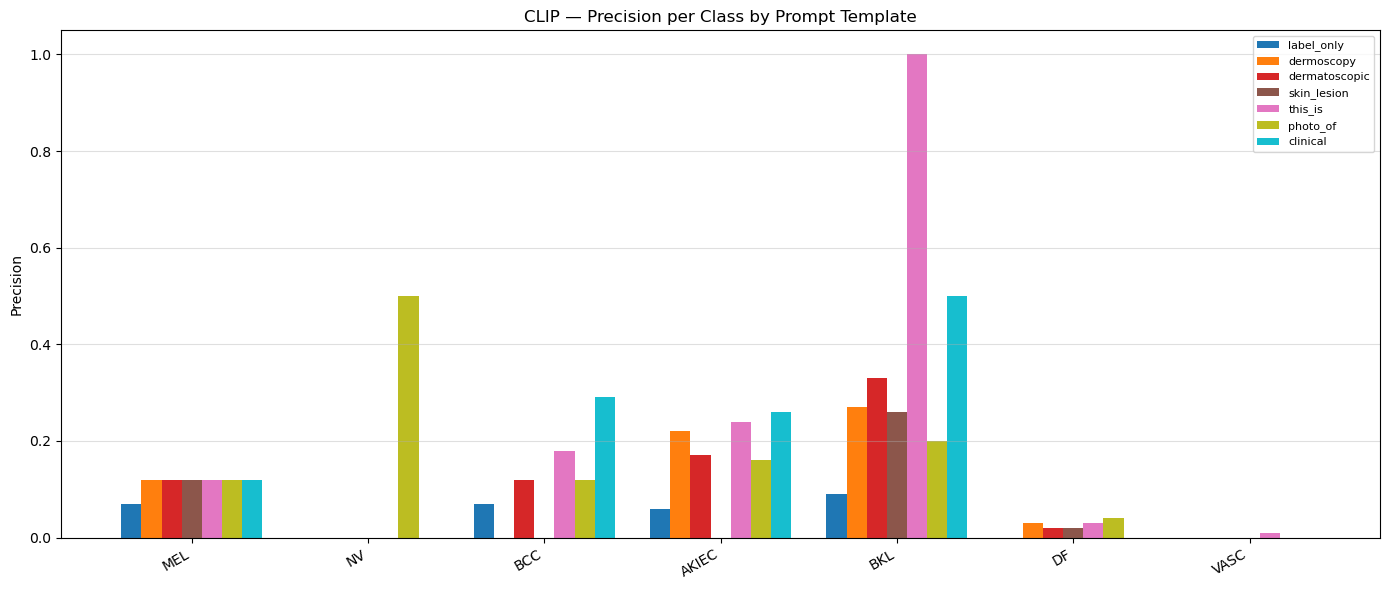

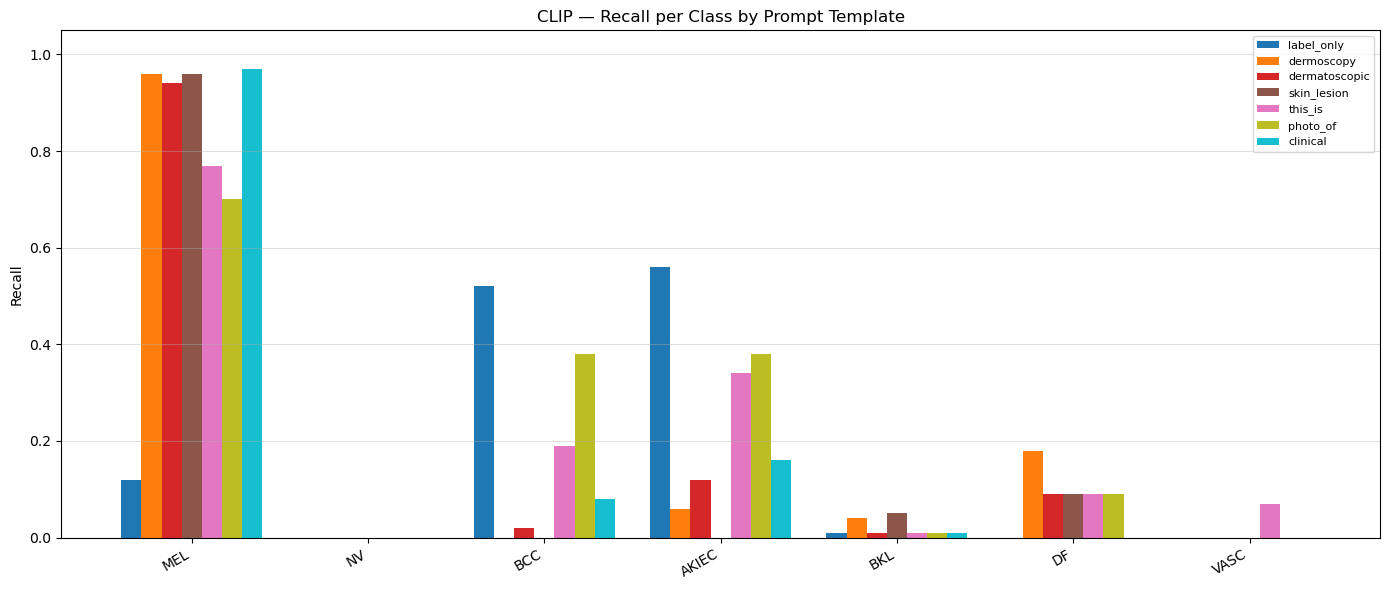

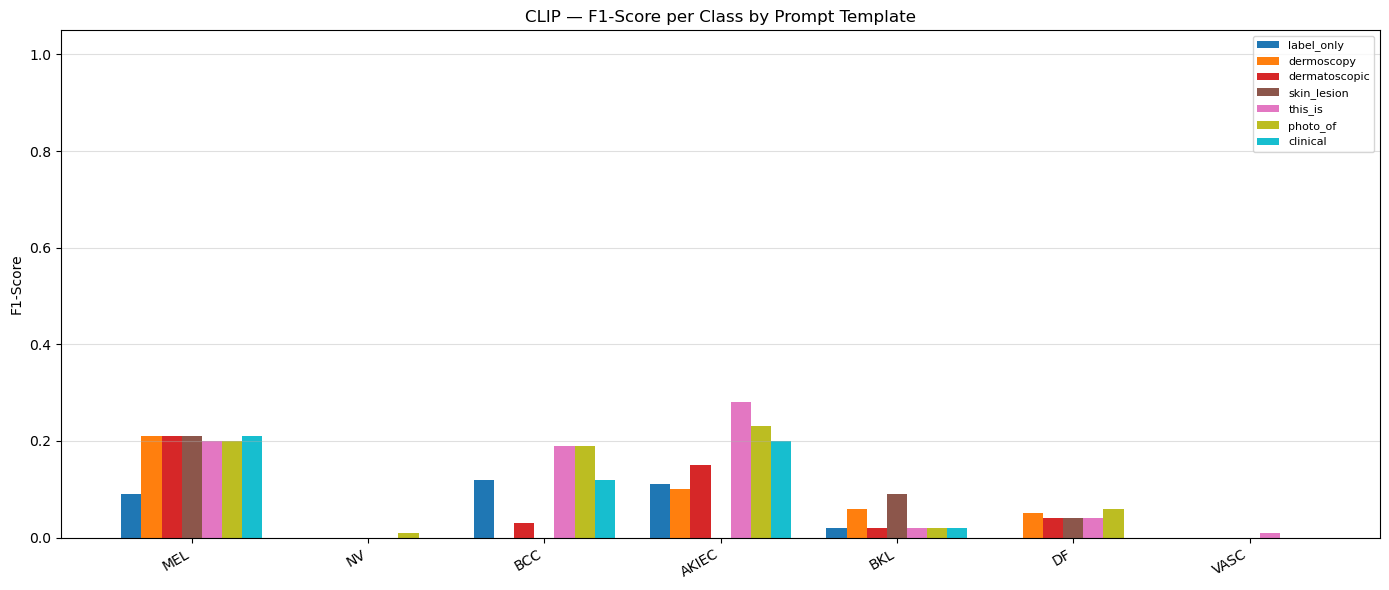

In [24]:
def parse_report(model_dir, tmpl):
    text = load_report(model_dir, tmpl)
    metrics = {}
    for cls in CLASS_NAMES:
        pattern = rf'\s+{re.escape(cls)}\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)'
        m = re.search(pattern, text)
        if m:
            metrics[cls] = {
                'precision': float(m.group(1)),
                'recall':    float(m.group(2)),
                'f1':        float(m.group(3)),
            }
    return metrics

clip_per_prompt = {tmpl: parse_report(CLIP_DIR, tmpl) for tmpl in TEMPLATES}

x      = np.arange(len(CLASS_NAMES))
width  = 0.8 / len(TEMPLATES)
colors = plt.cm.tab10(np.linspace(0, 1, len(TEMPLATES)))

for metric, ylabel in [('precision', 'Precision'), ('recall', 'Recall'), ('f1', 'F1-Score')]:
    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (tmpl, color) in enumerate(zip(TEMPLATES, colors)):
        vals = [clip_per_prompt[tmpl][cls][metric] for cls in CLASS_NAMES]
        ax.bar(x + i * width - (len(TEMPLATES) - 1) * width / 2, vals, width, label=tmpl, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(f'CLIP — {ylabel} per Class by Prompt Template')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

## Summary Metrics Table

In [5]:
print(f"{'Template':<20}  {'Accuracy':>10}  {'Macro AUC':>10}  {'Micro AUC':>10}")
print('-' * 58)
for name, r in sweep.items():
    print(f"{name:<20}  {r['accuracy']:>9.2f}%  {r['macro_auc']:>10.4f}  {r['micro_auc']:>10.4f}")

print('\nPer-class AUC')
print(f"{'Class':<25}", end='')
for name in TEMPLATES:
    print(f"  {name:>15}", end='')
print()
print('-' * (25 + 17 * len(TEMPLATES)))
for cls in CLASS_NAMES:
    print(f"{cls:<25}", end='')
    for name in TEMPLATES:
        print(f"  {sweep[name]['per_class_auc'][cls]:>15.4f}", end='')
    print()

Template                Accuracy   Macro AUC   Micro AUC
----------------------------------------------------------
label_only                 5.99%      0.5933      0.2944
dermoscopy                11.58%      0.6141      0.3429
dermatoscopic             11.18%      0.6010      0.2957
skin_lesion               11.38%      0.6008      0.3555
this_is                   10.98%      0.6134      0.2882
photo_of                  11.38%      0.5994      0.3199
clinical                  11.88%      0.6079      0.3241

Per-class AUC
Class                           label_only       dermoscopy    dermatoscopic      skin_lesion          this_is         photo_of         clinical
------------------------------------------------------------------------------------------------------------------------------------------------
MEL                                 0.5696           0.5869           0.6147           0.6101           0.5699           0.5727           0.5937
NV                                 

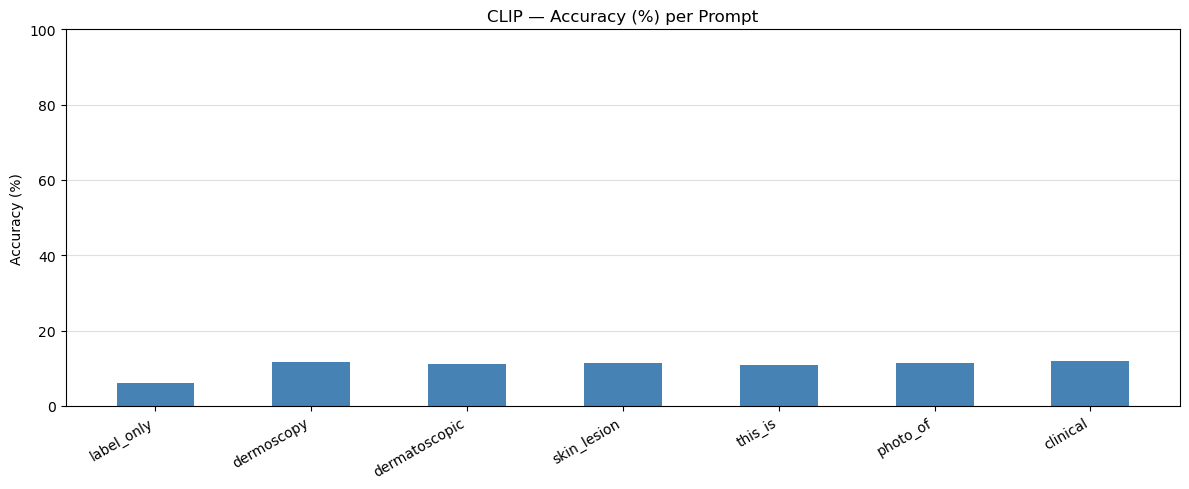

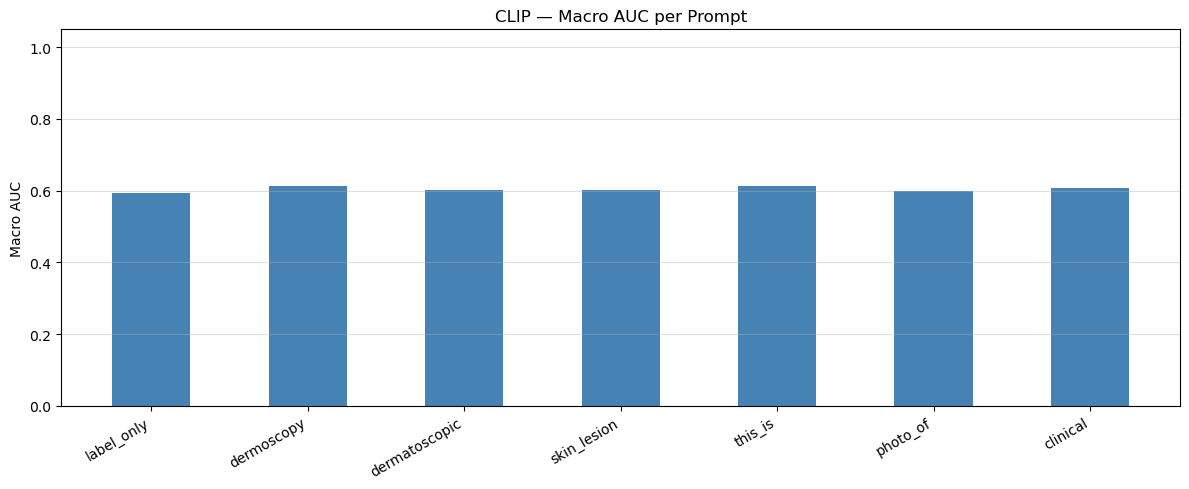

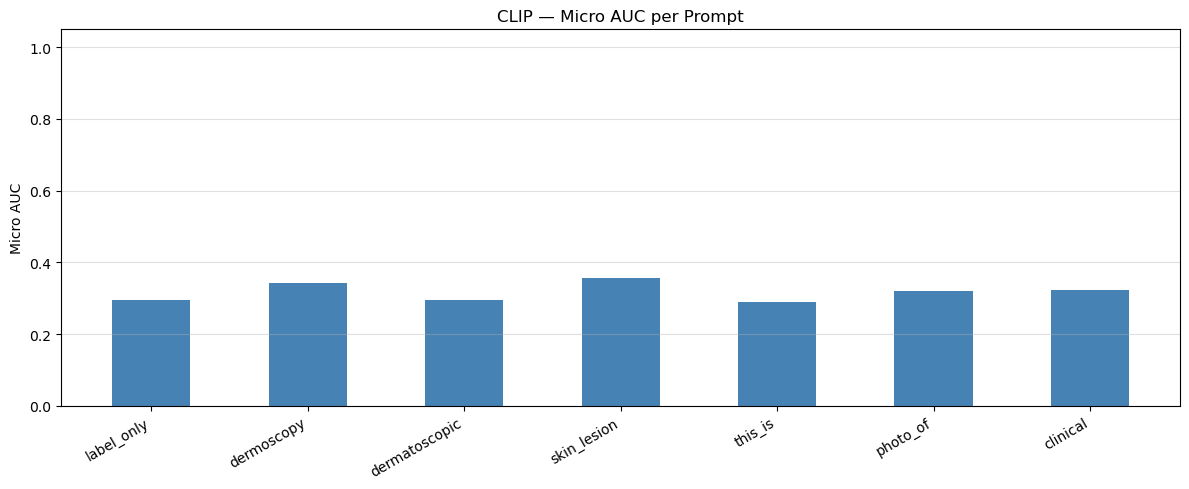

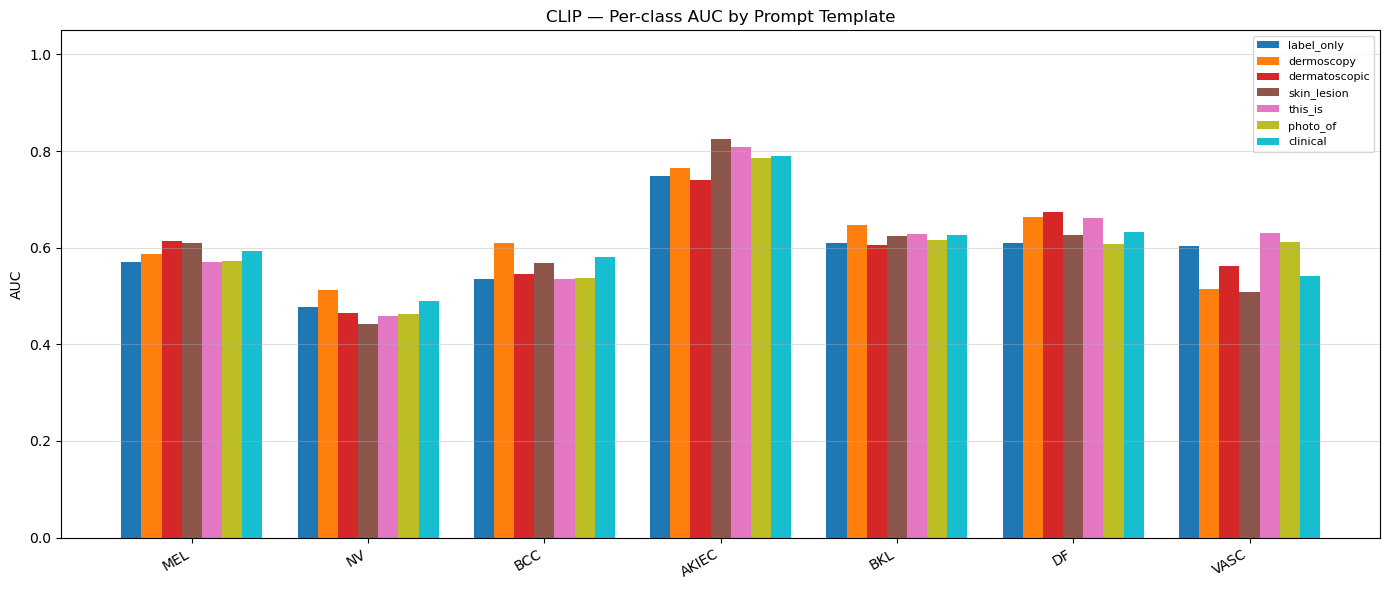

In [25]:
prompts    = list(sweep.keys())
x          = np.arange(len(prompts))
width      = 0.25
colors     = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

# Accuracy, Macro AUC, Micro AUC per prompt
for metric, ylabel in [('accuracy', 'Accuracy (%)'), ('macro_auc', 'Macro AUC'), ('micro_auc', 'Micro AUC')]:
    fig, ax = plt.subplots(figsize=(12, 5))
    vals = [sweep[p][metric] for p in prompts]
    ax.bar(x, vals, width=0.5, color='steelblue')
    ax.set_xticks(x)
    ax.set_xticklabels(prompts, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(f'CLIP — {ylabel} per Prompt')
    ax.set_ylim(0, 100 if metric == 'accuracy' else 1.05)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Per-class AUC per prompt
x2     = np.arange(len(CLASS_NAMES))
width2 = 0.8 / len(prompts)

fig, ax = plt.subplots(figsize=(14, 6))
for i, (tmpl, color) in enumerate(zip(prompts, plt.cm.tab10(np.linspace(0, 1, len(prompts))))):
    vals = [sweep[tmpl]['per_class_auc'][cls] for cls in CLASS_NAMES]
    ax.bar(x2 + i * width2 - (len(prompts) - 1) * width2 / 2, vals, width2, label=tmpl, color=color)
ax.set_xticks(x2)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('AUC')
ax.set_title('CLIP — Per-class AUC by Prompt Template')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
# Section 2 — DermLIP

## Prompt Sweep Table

In [6]:
sweep_d = derm_summary['prompt_sweep']
best_d  = derm_summary['best_config']['template']

print(f"{'Template':<20}  {'Template String':<45}  {'Accuracy':>10}  {'Macro AUC':>10}  {'Micro AUC':>10}")
print('-' * 100)
for name, r in sweep_d.items():
    marker = ' <-- best' if name == best_d else ''
    print(f"{name:<20}  {r['template']:<45}  {r['accuracy']:>9.2f}%  {r['macro_auc']:>10.4f}  {r['micro_auc']:>10.4f}{marker}")

Template              Template String                                  Accuracy   Macro AUC   Micro AUC
----------------------------------------------------------------------------------------------------
label_only            {c}                                                44.21%      0.8740      0.8310
dermoscopy            a dermoscopy image of {c}                          51.40%      0.8533      0.8489
dermatoscopic         a dermatoscopic image of {c}                       54.69%      0.8602      0.8590
skin_lesion           a skin lesion showing {c}                          54.09%      0.8745      0.8762
this_is               this is a skin image of {c}                        67.76%      0.8680      0.9062 <-- best
photo_of              a photo of {c}                                     60.38%      0.8604      0.8766
clinical              a clinical photograph of {c}                       49.70%      0.8523      0.8521


## Confusion Matrices — All Prompts

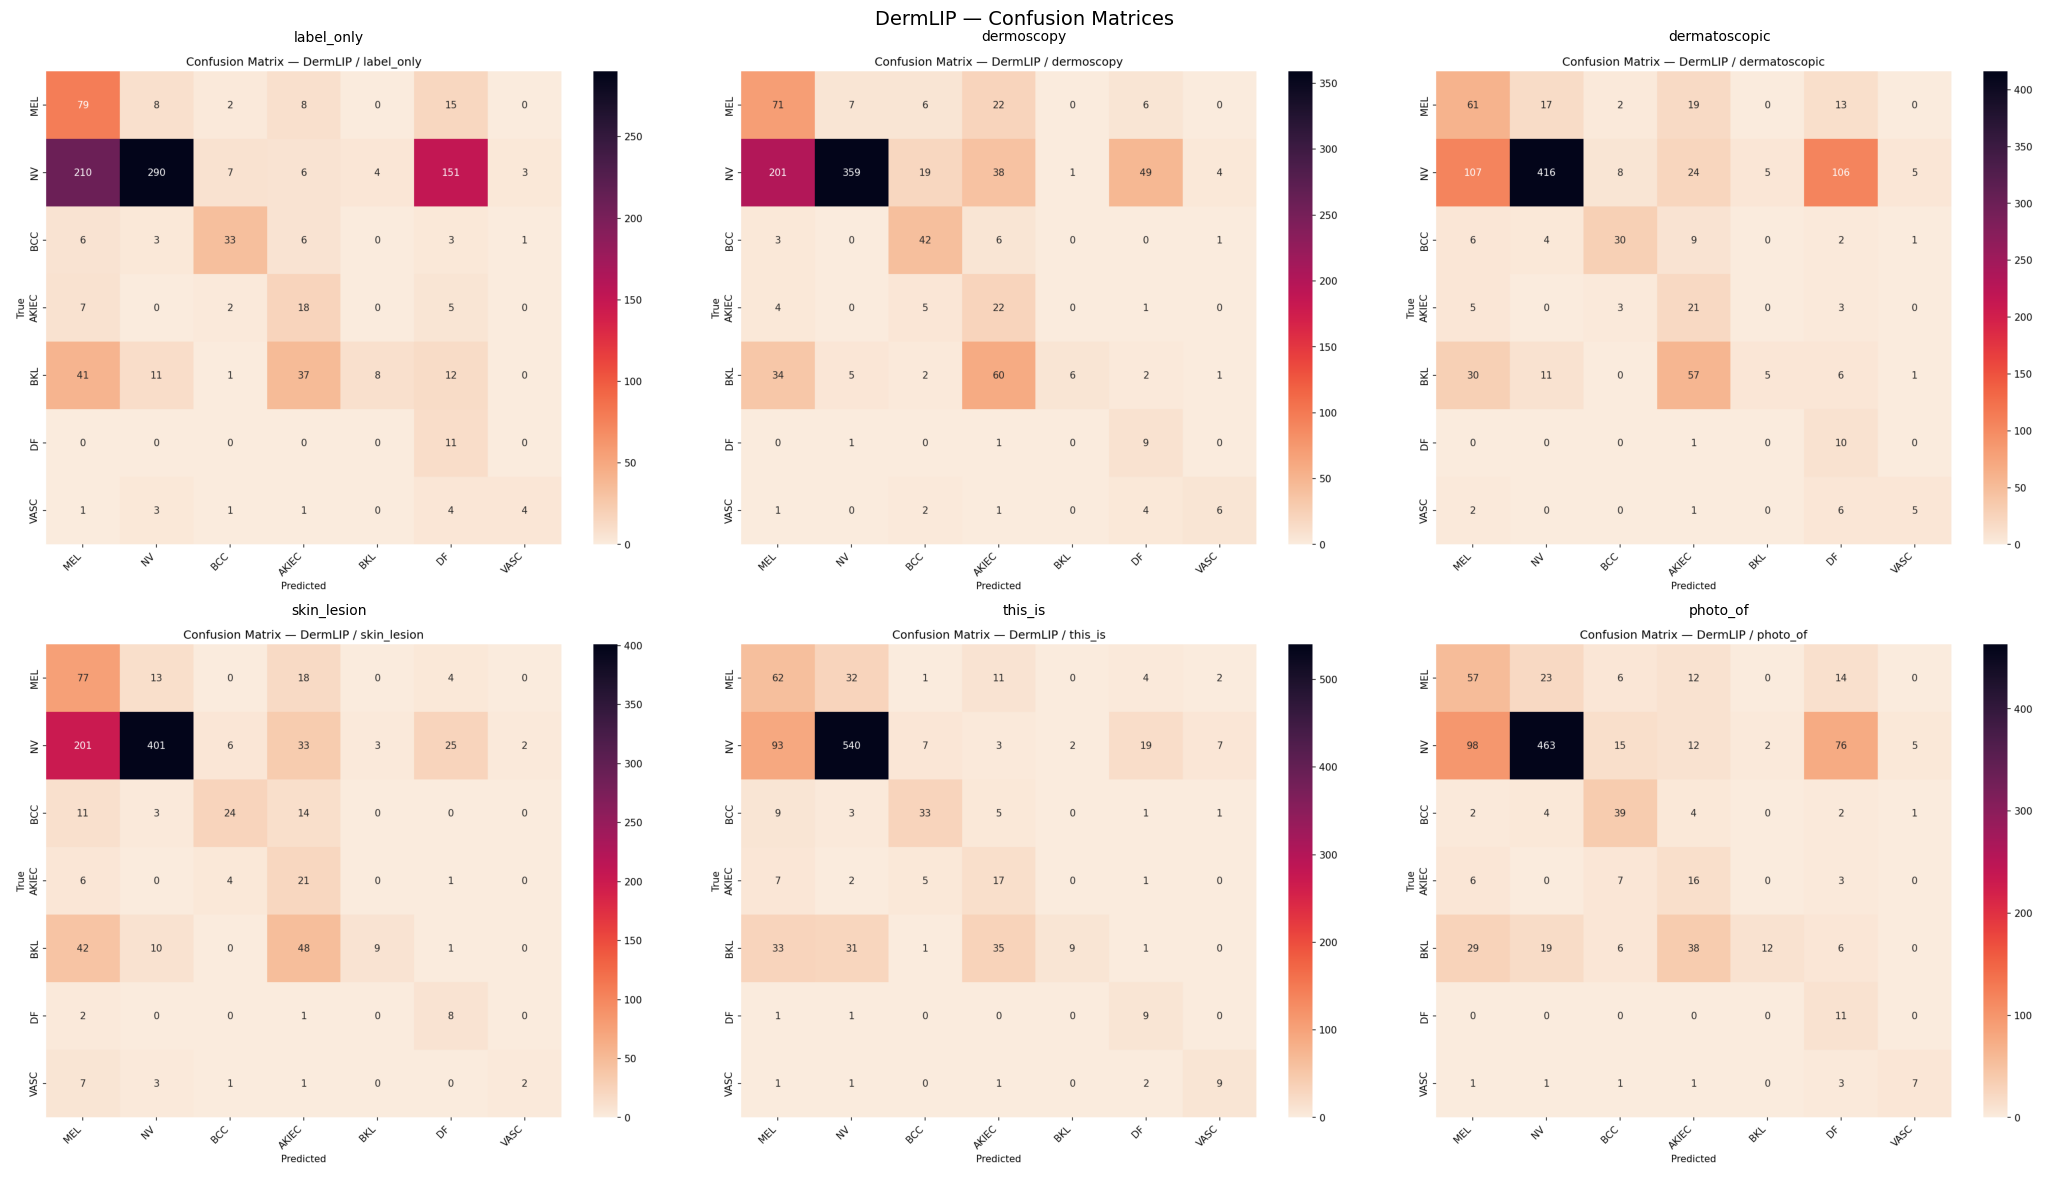

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
axes_flat = axes.flatten()
for ax, tmpl in zip(axes_flat, TEMPLATES):
    img_path = os.path.join(DERM_DIR, tmpl, 'confusion_matrix.png')
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(tmpl, fontsize=10)
    ax.axis('off')
# hide any unused axes if fewer than 6 templates
for ax in axes_flat[len(TEMPLATES):]:
    ax.axis('off')
plt.suptitle('DermLIP — Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

## Classification Reports — All Prompts

In [8]:
for tmpl in TEMPLATES:
    print(f'\n--- DermLIP / {tmpl} ---')
    print(load_report(DERM_DIR, tmpl))


--- DermLIP / label_only ---
Model: DermLIP
Template: label_only — "{c}"

              precision    recall  f1-score   support

         MEL       0.23      0.71      0.35       112
          NV       0.92      0.43      0.59       671
         BCC       0.72      0.63      0.67        52
       AKIEC       0.24      0.56      0.33        32
         BKL       0.67      0.07      0.13       110
          DF       0.05      1.00      0.10        11
        VASC       0.50      0.29      0.36        14

    accuracy                           0.44      1002
   macro avg       0.48      0.53      0.36      1002
weighted avg       0.77      0.44      0.50      1002


--- DermLIP / dermoscopy ---
Model: DermLIP
Template: dermoscopy — "a dermoscopy image of {c}"

              precision    recall  f1-score   support

         MEL       0.23      0.63      0.33       112
          NV       0.97      0.54      0.69       671
         BCC       0.55      0.81      0.66        52
       AKIEC  

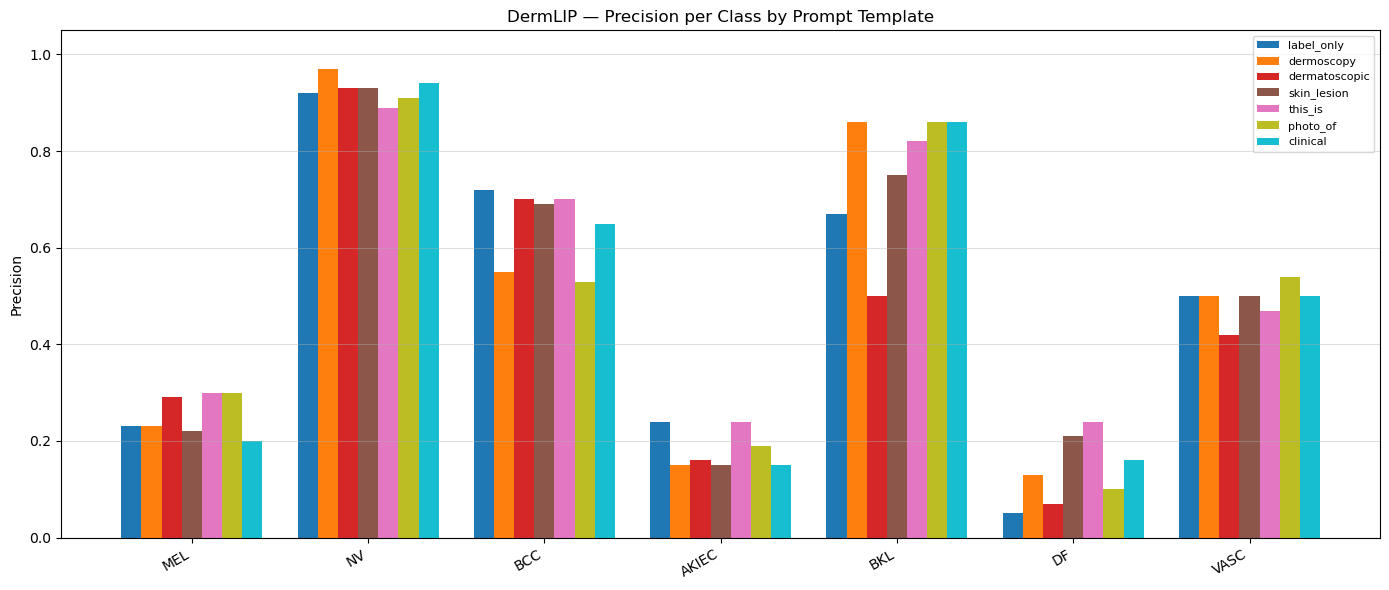

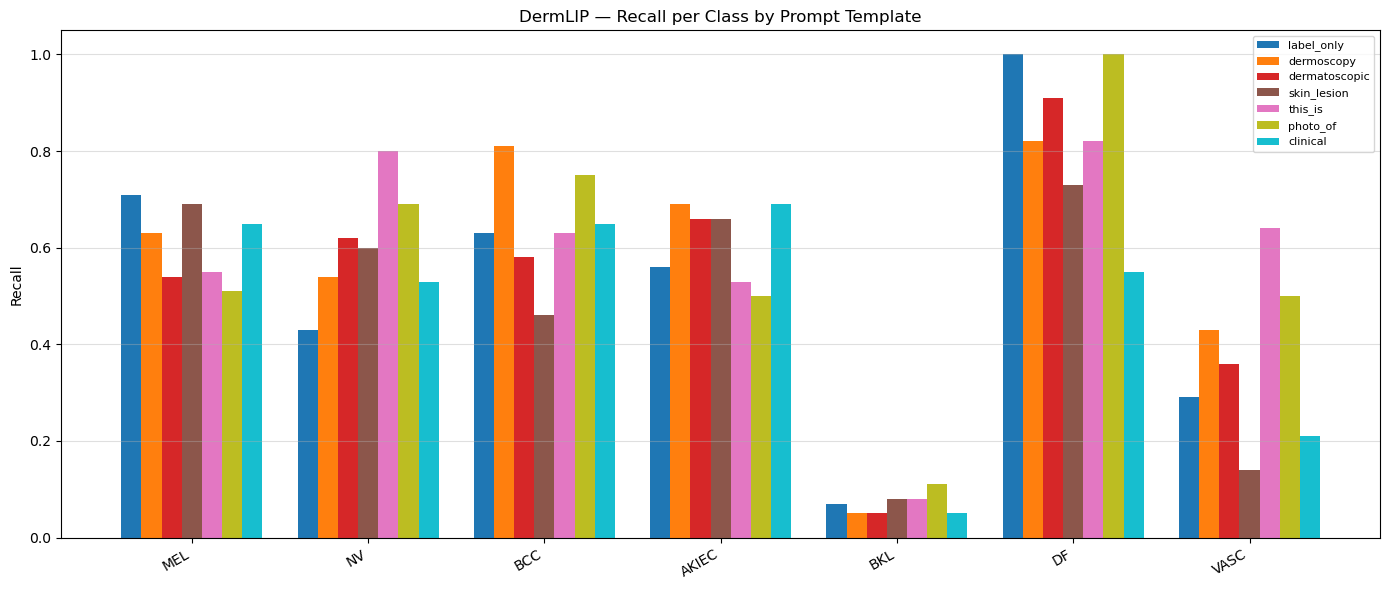

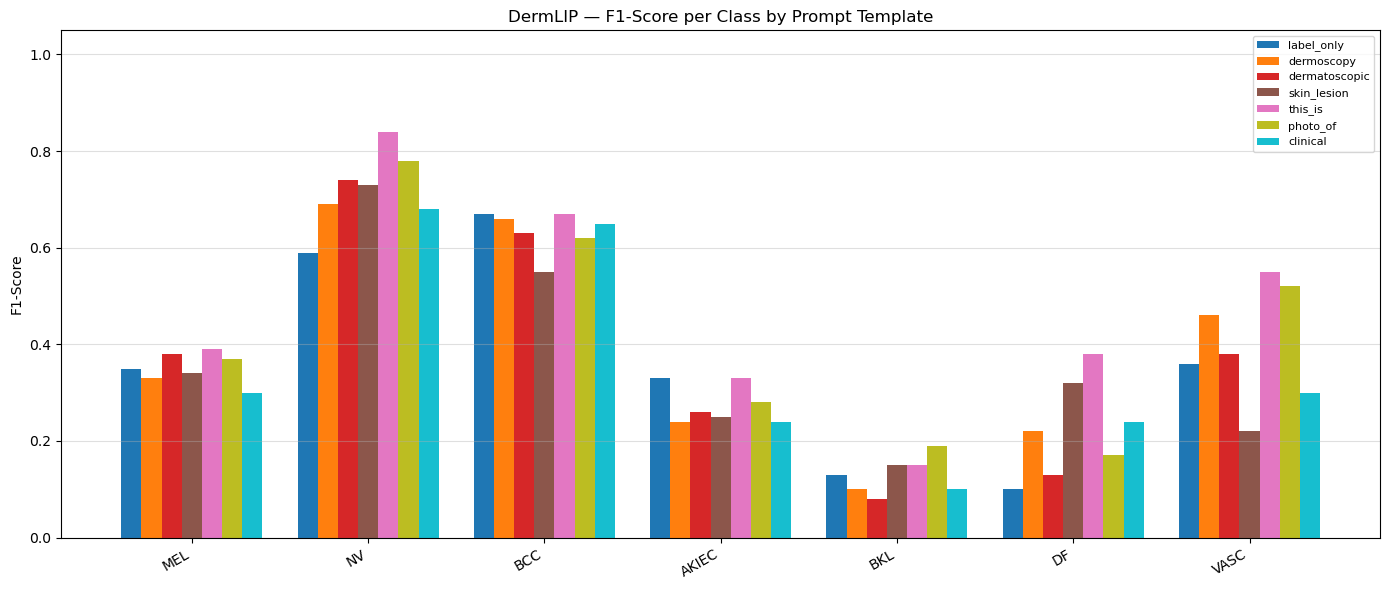

In [26]:
def parse_report(model_dir, tmpl):
    text = load_report(model_dir, tmpl)
    metrics = {}
    for cls in CLASS_NAMES:
        pattern = rf'\s+{re.escape(cls)}\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)'
        m = re.search(pattern, text)
        if m:
            metrics[cls] = {
                'precision': float(m.group(1)),
                'recall':    float(m.group(2)),
                'f1':        float(m.group(3)),
            }
    return metrics

derm_per_prompt = {tmpl: parse_report(DERM_DIR, tmpl) for tmpl in TEMPLATES}

x      = np.arange(len(CLASS_NAMES))
width  = 0.8 / len(TEMPLATES)
colors = plt.cm.tab10(np.linspace(0, 1, len(TEMPLATES)))

for metric, ylabel in [('precision', 'Precision'), ('recall', 'Recall'), ('f1', 'F1-Score')]:
    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (tmpl, color) in enumerate(zip(TEMPLATES, colors)):
        vals = [derm_per_prompt[tmpl][cls][metric] for cls in CLASS_NAMES]
        ax.bar(x + i * width - (len(TEMPLATES) - 1) * width / 2, vals, width, label=tmpl, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(f'DermLIP — {ylabel} per Class by Prompt Template')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

## Summary Metrics Table

In [27]:
print(f"{'Template':<20}  {'Accuracy':>10}  {'Macro AUC':>10}  {'Micro AUC':>10}")
print('-' * 58)
for name, r in sweep_d.items():
    print(f"{name:<20}  {r['accuracy']:>9.2f}%  {r['macro_auc']:>10.4f}  {r['micro_auc']:>10.4f}")

print('\nPer-class AUC')
print(f"{'Class':<25}", end='')
for name in TEMPLATES:
    print(f"  {name:>15}", end='')
print()
print('-' * (25 + 17 * len(TEMPLATES)))
for cls in CLASS_NAMES:
    print(f"{cls:<25}", end='')
    for name in TEMPLATES:
        print(f"  {sweep_d[name]['per_class_auc'][cls]:>15.4f}", end='')
    print()

Template                Accuracy   Macro AUC   Micro AUC
----------------------------------------------------------
label_only                44.21%      0.8740      0.8310
dermoscopy                51.40%      0.8533      0.8489
dermatoscopic             54.69%      0.8602      0.8590
skin_lesion               54.09%      0.8745      0.8762
this_is                   67.76%      0.8680      0.9062
photo_of                  60.38%      0.8604      0.8766
clinical                  49.70%      0.8523      0.8521

Per-class AUC
Class                           label_only       dermoscopy    dermatoscopic      skin_lesion          this_is         photo_of         clinical
------------------------------------------------------------------------------------------------------------------------------------------------
MEL                                 0.7527           0.7042           0.7371           0.7725           0.7304           0.7260           0.7133
NV                                 

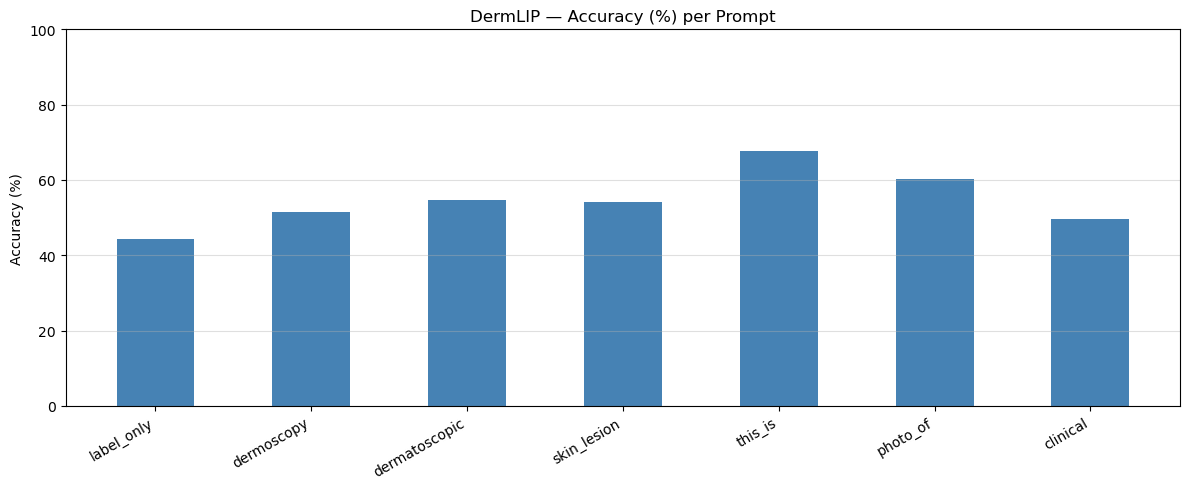

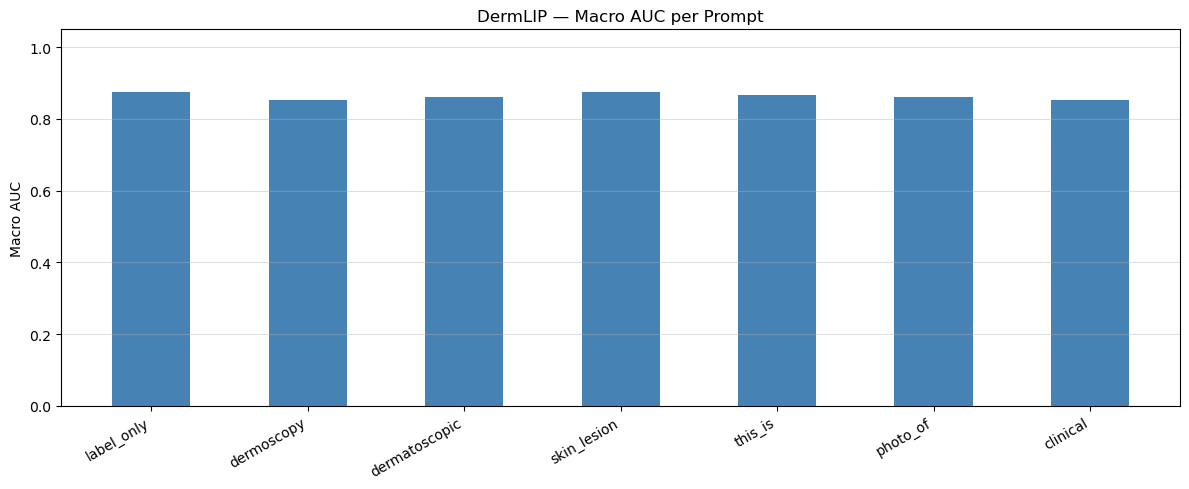

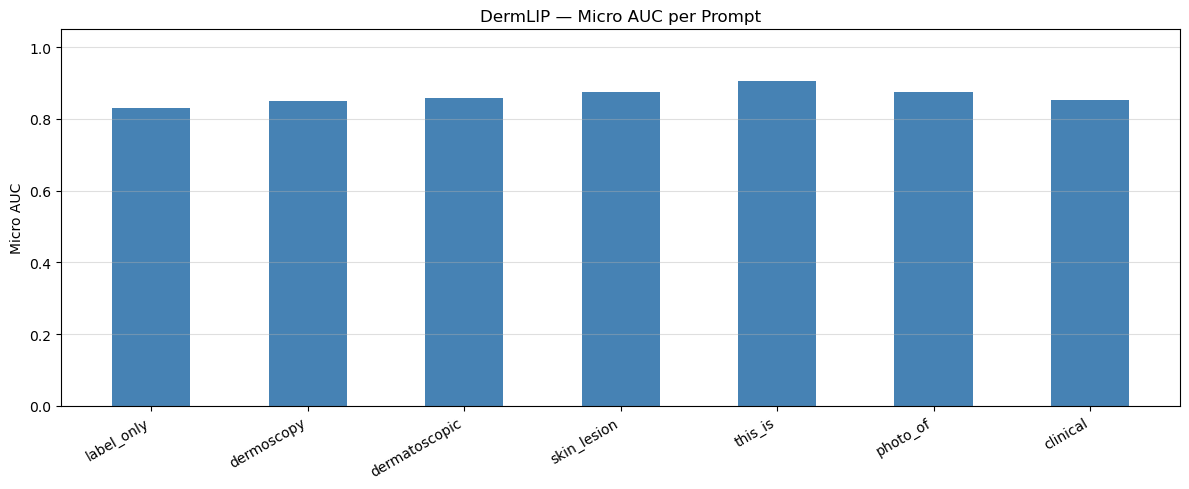

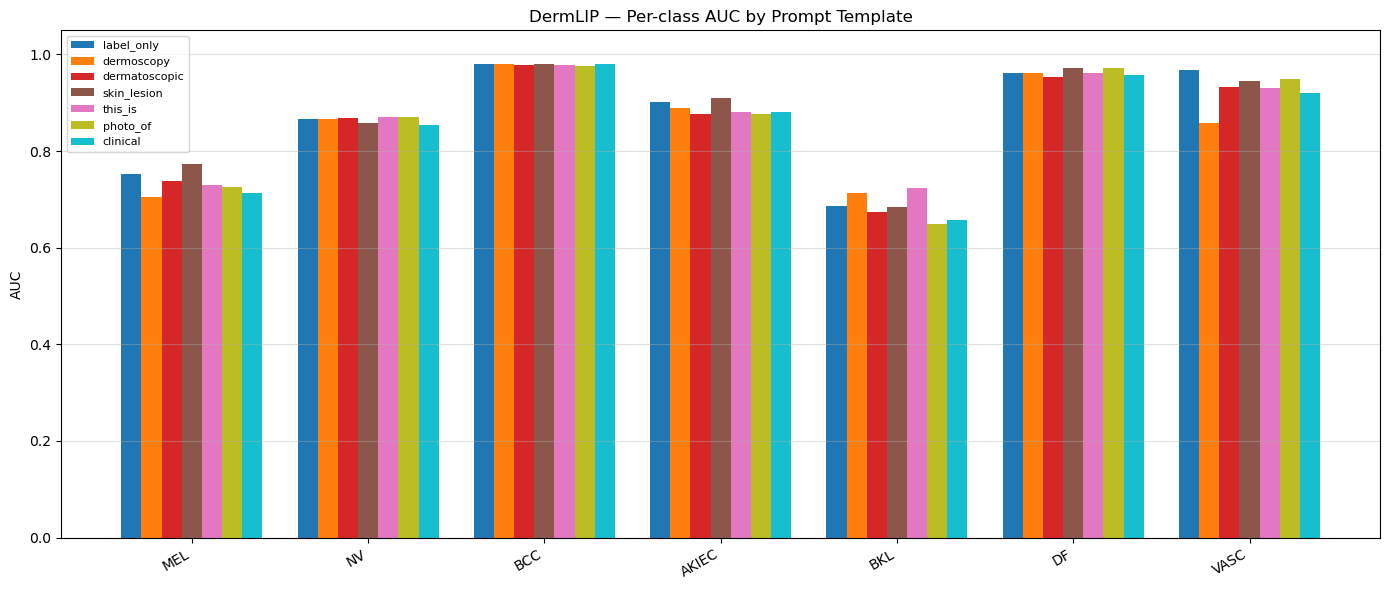

In [29]:
prompts    = list(sweep_d.keys())
x          = np.arange(len(prompts))
width      = 0.25
colors     = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

# Accuracy, Macro AUC, Micro AUC per prompt
for metric, ylabel in [('accuracy', 'Accuracy (%)'), ('macro_auc', 'Macro AUC'), ('micro_auc', 'Micro AUC')]:
    fig, ax = plt.subplots(figsize=(12, 5))
    vals = [sweep_d[p][metric] for p in prompts]
    ax.bar(x, vals, width=0.5, color='steelblue')
    ax.set_xticks(x)
    ax.set_xticklabels(prompts, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(f'DermLIP — {ylabel} per Prompt')
    ax.set_ylim(0, 100 if metric == 'accuracy' else 1.05)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Per-class AUC per prompt
x2     = np.arange(len(CLASS_NAMES))
width2 = 0.8 / len(prompts)

fig, ax = plt.subplots(figsize=(14, 6))
for i, (tmpl, color) in enumerate(zip(prompts, plt.cm.tab10(np.linspace(0, 1, len(prompts))))):
    vals = [sweep_d[tmpl]['per_class_auc'][cls] for cls in CLASS_NAMES]
    ax.bar(x2 + i * width2 - (len(prompts) - 1) * width2 / 2, vals, width2, label=tmpl, color=color)
ax.set_xticks(x2)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('AUC')
ax.set_title('DermLIP — Per-class AUC by Prompt Template')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
# Section 3 — Best CLIP vs Best DermLIP

In [10]:
best_clip = clip_summary['best_config']
best_derm = derm_summary['best_config']

print(f"CLIP    best template: '{best_clip['template']}' — \"{best_clip['template_str']}\"")
print(f"DermLIP best template: '{best_derm['template']}' — \"{best_derm['template_str']}\"")

CLIP    best template: 'clinical' — "a clinical photograph of {c}"
DermLIP best template: 'this_is' — "this is a skin image of {c}"


## Head-to-Head Metrics

In [11]:
print(f"{'Model':<12}  {'Template':<20}  {'Accuracy':>10}  {'Macro AUC':>10}  {'Micro AUC':>10}")
print('-' * 70)
for label, cfg in [('CLIP', best_clip), ('DermLIP', best_derm)]:
    print(f"{label:<12}  {cfg['template']:<20}  {cfg['accuracy']:>9.2f}%  {cfg['macro_auc']:>10.4f}  {cfg['micro_auc']:>10.4f}")

print('\nPer-class AUC')
print(f"{'Class':<25}  {'CLIP':>10}  {'DermLIP':>10}  {'Delta':>10}")
print('-' * 60)
for cls in CLASS_NAMES:
    c = best_clip['per_class_auc'][cls]
    d = best_derm['per_class_auc'][cls]
    print(f"{cls:<25}  {c:>10.4f}  {d:>10.4f}  {d - c:>+10.4f}")

Model         Template                Accuracy   Macro AUC   Micro AUC
----------------------------------------------------------------------
CLIP          clinical                  11.88%      0.6079      0.3241
DermLIP       this_is                   67.76%      0.8680      0.9062

Per-class AUC
Class                            CLIP     DermLIP       Delta
------------------------------------------------------------
MEL                            0.5937      0.7304     +0.1367
NV                             0.4905      0.8709     +0.3804
BCC                            0.5804      0.9787     +0.3983
AKIEC                          0.7892      0.8800     +0.0908
BKL                            0.6272      0.7227     +0.0955
DF                             0.6335      0.9621     +0.3286
VASC                           0.5406      0.9314     +0.3908


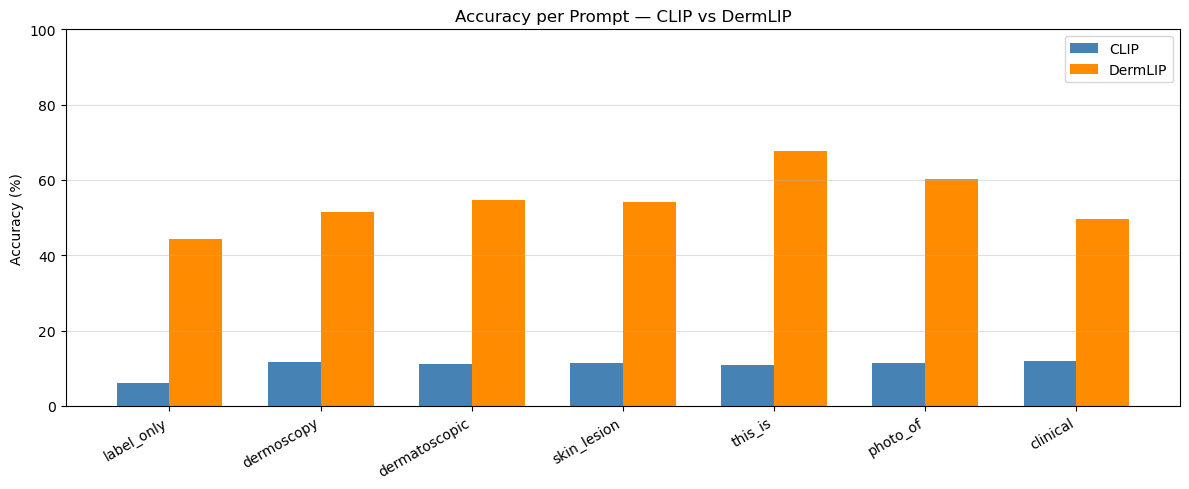

In [18]:
prompts    = list(clip_summary['prompt_sweep'].keys())
clip_accs  = [clip_summary['prompt_sweep'][p]['accuracy'] for p in prompts]
derm_accs  = [derm_summary['prompt_sweep'][p]['accuracy'] for p in prompts]

x     = np.arange(len(prompts))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, clip_accs, width, label='CLIP',    color='steelblue')
ax.bar(x + width/2, derm_accs, width, label='DermLIP', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(prompts, rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy per Prompt — CLIP vs DermLIP')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## Confusion Matrices — Best Prompts

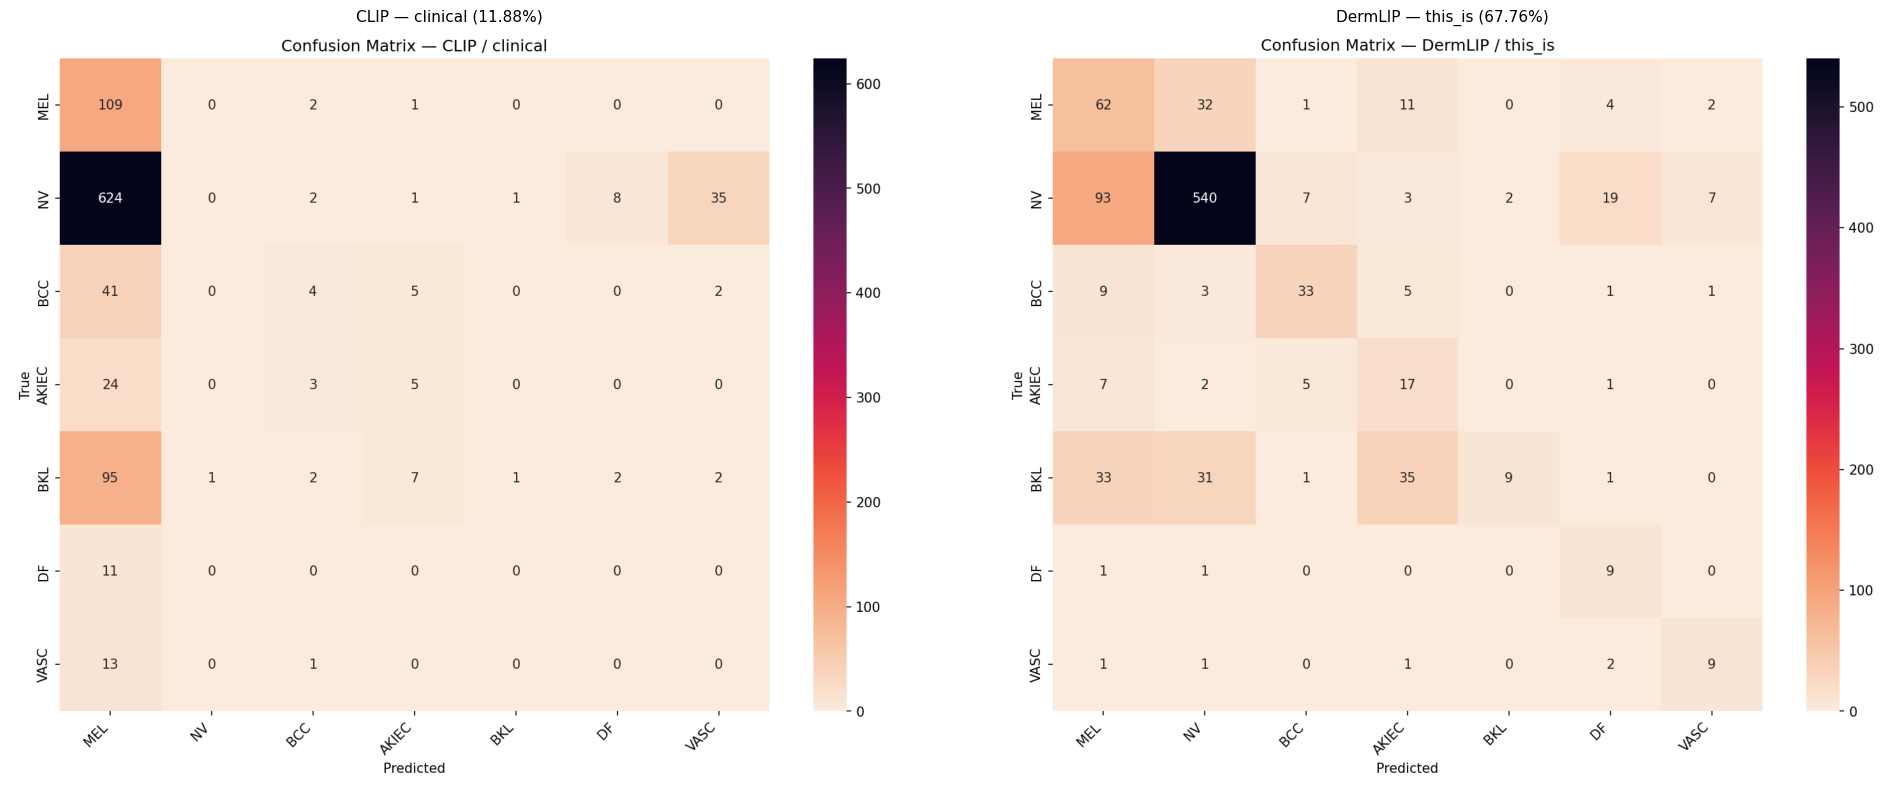

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, (label, model_dir, cfg) in zip(axes, [
    ('CLIP',    CLIP_DIR, best_clip),
    ('DermLIP', DERM_DIR, best_derm),
]):
    img_path = os.path.join(model_dir, cfg['template'], 'confusion_matrix.png')
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(f"{label} — {cfg['template']} ({cfg['accuracy']:.2f}%)", fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Classification Reports — Best Prompts

In [13]:
print('--- CLIP (best) ---')
print(load_report(CLIP_DIR, best_clip['template']))
print('\n--- DermLIP (best) ---')
print(load_report(DERM_DIR, best_derm['template']))

--- CLIP (best) ---
Model: CLIP
Template: clinical — "a clinical photograph of {c}"

              precision    recall  f1-score   support

         MEL       0.12      0.97      0.21       112
          NV       0.00      0.00      0.00       671
         BCC       0.29      0.08      0.12        52
       AKIEC       0.26      0.16      0.20        32
         BKL       0.50      0.01      0.02       110
          DF       0.00      0.00      0.00        11
        VASC       0.00      0.00      0.00        14

    accuracy                           0.12      1002
   macro avg       0.17      0.17      0.08      1002
weighted avg       0.09      0.12      0.04      1002


--- DermLIP (best) ---
Model: DermLIP
Template: this_is — "this is a skin image of {c}"

              precision    recall  f1-score   support

         MEL       0.30      0.55      0.39       112
          NV       0.89      0.80      0.84       671
         BCC       0.70      0.63      0.67        52
       AKIE

## Per-class AUC Bar Chart

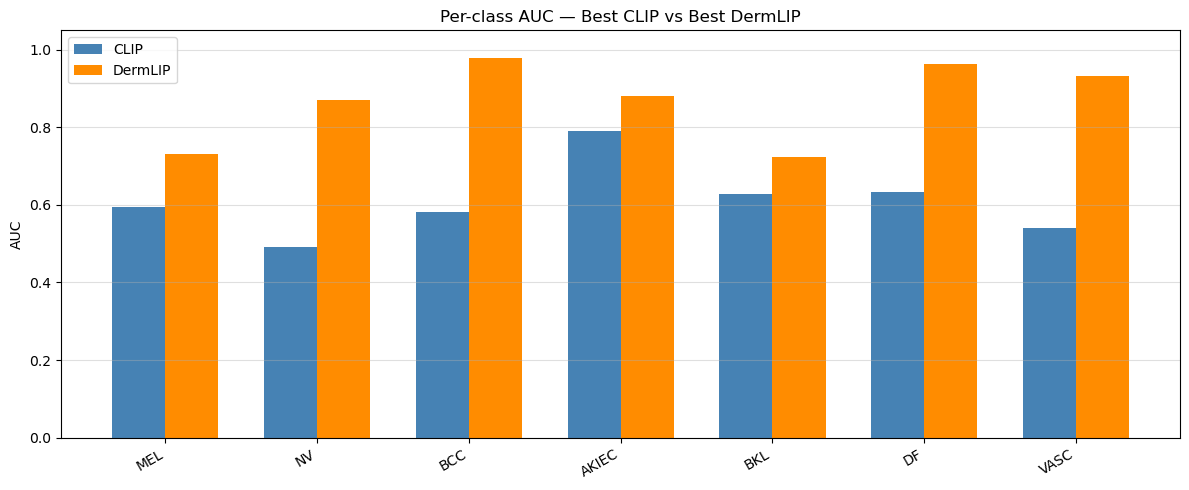

In [14]:
x = np.arange(len(CLASS_NAMES))
width  = 0.35
clip_aucs = [best_clip['per_class_auc'][c] for c in CLASS_NAMES]
derm_aucs = [best_derm['per_class_auc'][c] for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, clip_aucs,  width, label='CLIP',    color='steelblue')
ax.bar(x + width/2, derm_aucs, width, label='DermLIP', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('AUC')
ax.set_title('Per-class AUC — Best CLIP vs Best DermLIP')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()